In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc
from utils import performance_dict

In [2]:
# Load data
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered_andrew.npz', allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]
    y_positive_train = data["y_positive_train"]
    y_positive_test = data["y_positive_test"]

In [3]:
with np.load('/home/server/Projects/data/AKI/preop_trainable/normalized.npz', allow_pickle=True) as data:
    X_train=data["X_train_normalized"]
    X_test=data["X_test_normalized"]
    y_train=data["y_train_normalized"]
    y_test=data["y_test_normalized"]
    y_binary_train=data["y_binary_train_normalized"]
    y_binary_test=data["y_binary_test_normalized"]
    y_positive_train=data["y_positive_train_normalized"]
    y_positive_test=data["y_positive_test_normalized"]

In [7]:
# Train model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
print("training")
regressor.fit(X_train, y_positive_train)

training


RandomForestRegressor(random_state=42)

In [10]:
# Predict
y_pred = regressor.predict(X_test)

# Regression Metrics
mae = mean_absolute_error(y_positive_test, y_pred)
mse = mean_squared_error(y_positive_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_positive_test, y_pred)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'R-squared: {r2:.4f}')

Mean Absolute Error: 0.1232
Mean Squared Error: 0.0645
Root Mean Squared Error: 0.2539
R-squared: 0.0478


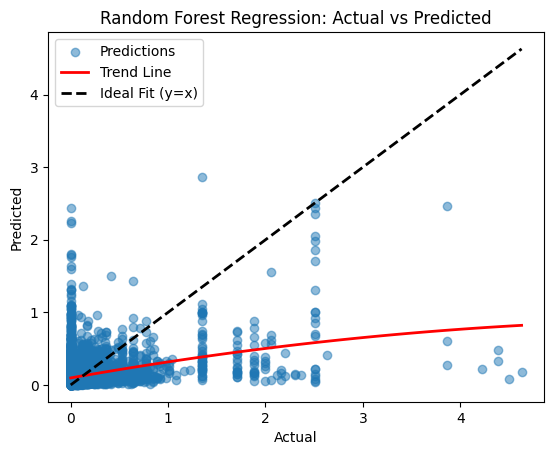

In [12]:
# Scatter plot of actual vs predicted values
plt.figure()
plt.scatter(y_positive_test, y_pred, alpha=0.5, label="Predictions")

# Fit a polynomial trend line (degree=2)
coeffs = np.polyfit(y_positive_test, y_pred, deg=2)
poly_eq = np.poly1d(coeffs)
trend_x = np.linspace(y_positive_test.min(), y_positive_test.max(), 100)
trend_y = poly_eq(trend_x)

# Plot the trend line
plt.plot(trend_x, trend_y, color='red', linewidth=2, label="Trend Line")

# Identity line (y = x)
plt.plot([y_positive_test.min(), y_positive_test.max()], [y_positive_test.min(), y_positive_test.max()], 'k--', lw=2, label="Ideal Fit (y=x)")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [8]:
# Train classification model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_binary_train)

RandomForestClassifier(random_state=42)

In [9]:
# Predict binary outcomes
y_pred_binary = classifier.predict(X_test)

# Classification Metrics
accuracy = accuracy_score(y_binary_test, y_pred_binary)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred_binary)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred_binary)
print('Classification Report:')
print(report)

Accuracy: 0.94
Confusion Matrix:
[[9564   32]
 [ 631   28]]
Classification Report:
              precision    recall  f1-score   support

       False       0.94      1.00      0.97      9596
        True       0.47      0.04      0.08       659

    accuracy                           0.94     10255
   macro avg       0.70      0.52      0.52     10255
weighted avg       0.91      0.94      0.91     10255



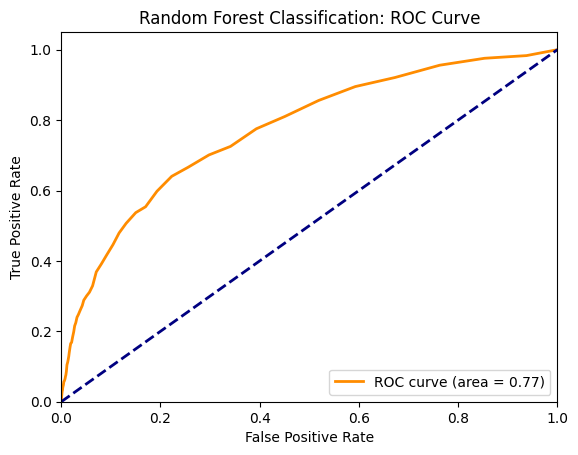

In [10]:
# Predict probabilities for ROC curve
y_prob = classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Classification: ROC Curve')
plt.legend(loc='lower right')
plt.show()